# WCS 07 — Reconstructed image_rd × rdls Cross-Matches

**Purpose:** Use `image-radec.fits` and `rdls.fits` to reconstruct additional WCS matches independently of `corr.fits`, covering the full detector.

**Main question:** Can we find valid post-solve matches across the whole detector — especially on the right side — by cross-matching all WCS-transformed image detections to the reference star catalog?

**Core idea:**
- `image_rd` contains every detected source converted to RA/Dec by the solved WCS.
- `rdls` contains reference/catalog stars in RA/Dec.
- Cross-matching these two sky-coordinate tables gives us an independent post-solve residual map.

**Important caveat:** `image_rd` RA/Dec values are *produced by the solved WCS*, so matching them to `rdls` is not an independent plate solve. It tells us whether WCS-transformed image detections land near reference stars — a valid WCS residual diagnostic, but not a ground-truth check. Coherent spatial gradients in the residuals are the real signal.

In [1]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u

OUT_DIR  = ROOT / 'out' / 'wcs_diagnostics'
PROD_DIR = OUT_DIR / 'products'
CACHE    = OUT_DIR / 'platesolve_result.pkl'

if not CACHE.exists():
    raise FileNotFoundError(f'Run wcs_01 first to create {CACHE}')
with open(CACHE, 'rb') as f:
    result = pickle.load(f)

with afits.open(sorted((ROOT / 'data').glob('*.fit'))[0]) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

cd11 = result.header.get('CD1_1', 0)
cd21 = result.header.get('CD2_1', 0)
plate_scale = np.hypot(cd11, cd21) * 3600  # arcsec/px

print(f'Image: {w} x {h} px   Plate scale: {plate_scale:.1f} arcsec/px')

Image: 3096 x 2080 px   Plate scale: 80.9 arcsec/px


In [2]:
def _load_fits_table(path, label):
    p = Path(path)
    if not p.exists():
        print(f'  {label}: NOT FOUND')
        return None
    with afits.open(p) as hdul:
        tbl_hdu = next(
            (h for h in hdul if isinstance(h, (afits.BinTableHDU, afits.TableHDU))), None
        )
        if tbl_hdu is None:
            return None
        t = Table(tbl_hdu.data)
    print(f'  {label}: {len(t)} rows | cols: {t.colnames}')
    return t

def _fallback(tbl, attr):
    if tbl is not None:
        return tbl
    t = getattr(result, attr, None)
    if t is not None:
        print(f'  {attr}: using in-memory fallback ({len(t)} rows)')
    return t

def gcol(tbl, *names):
    if tbl is None:
        return None
    lower = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        key = lower.get(n.strip().lower())
        if key is not None:
            return np.asarray(tbl[key], dtype=float)
    return None

print('Loading product tables:')
imgrd_tbl = _load_fits_table(PROD_DIR / 'image-radec.fits', 'image_rd')
rdls_tbl  = _load_fits_table(PROD_DIR / 'rdls.fits',        'rdls    ')
corr_tbl  = _load_fits_table(PROD_DIR / 'corr.fits',        'corr    ')

imgrd_tbl = _fallback(imgrd_tbl, 'image_radec_table')
rdls_tbl  = _fallback(rdls_tbl,  'rdls_table')
corr_tbl  = _fallback(corr_tbl,  'corr_table')

imgrd_ra  = gcol(imgrd_tbl, 'ra')
imgrd_dec = gcol(imgrd_tbl, 'dec')
imgrd_x   = gcol(imgrd_tbl, 'x')
imgrd_y   = gcol(imgrd_tbl, 'y')
rdls_ra   = gcol(rdls_tbl,  'RA')
rdls_dec  = gcol(rdls_tbl,  'DEC')
corr_fx   = gcol(corr_tbl,  'field_x')
corr_fy   = gcol(corr_tbl,  'field_y')

assert imgrd_ra is not None, 'image_rd ra column missing — check PROD_DIR'
assert rdls_ra  is not None, 'rdls RA column missing — check PROD_DIR'

print(f'\nimage_rd : {len(imgrd_ra)} sky positions')
print(f'rdls     : {len(rdls_ra)} reference stars')
print(f'corr     : {len(corr_fx) if corr_fx is not None else 0} matches (for comparison)')

Loading product tables:
  image_rd: 255 rows | cols: ['ra', 'dec', 'x', 'y']
  rdls    : 179 rows | cols: ['MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG', 'RA', 'DEC']
  corr    : 48 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']

image_rd : 255 sky positions
rdls     : 179 reference stars
corr     : 48 matches (for comparison)


In [3]:
# Build SkyCoord objects and do nearest-neighbor matching in sky coordinates
image_sky = SkyCoord(ra=imgrd_ra * u.deg, dec=imgrd_dec * u.deg)
ref_sky   = SkyCoord(ra=rdls_ra  * u.deg, dec=rdls_dec  * u.deg)

# Project rdls to pixel for later use
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    rdls_px_all, rdls_py_all = wcs.world_to_pixel_values(rdls_ra, rdls_dec)

# For each image detection, find nearest rdls reference star
idx_nn, sep_nn, _ = image_sky.match_to_catalog_sky(ref_sky)
sep_as = sep_nn.arcsec
sep_px = sep_as / plate_scale

print('Nearest-neighbor match stats (all image detections vs rdls):')
print(f'  Median sep    : {np.median(sep_as):.1f}"  ({np.median(sep_px):.2f} px)')
print(f'  90th pct      : {np.percentile(sep_as, 90):.1f}"  ({np.percentile(sep_px, 90):.2f} px)')
print(f'  Max sep       : {sep_as.max():.1f}"  ({sep_px.max():.2f} px)')
print()
print('Fraction of image sources with nearest rdls star within threshold:')
for thr_px in [0.5, 1.0, 2.0, 3.0, 5.0]:
    thr_as = thr_px * plate_scale
    n = int((sep_as <= thr_as).sum())
    print(f'  <= {thr_px:.1f} px ({thr_as:.0f}"): {n} / {len(image_sky)}')

Nearest-neighbor match stats (all image detections vs rdls):
  Median sep    : 4729.9"  (58.45 px)
  90th pct      : 10920.6"  (134.94 px)
  Max sep       : 15454.8"  (190.97 px)

Fraction of image sources with nearest rdls star within threshold:
  <= 0.5 px (40"): 1 / 255
  <= 1.0 px (81"): 16 / 255
  <= 2.0 px (162"): 33 / 255
  <= 3.0 px (243"): 36 / 255
  <= 5.0 px (405"): 43 / 255


In [4]:
def one_to_one_match(ref_idx_per_img, sep_arcsec, max_sep_arcsec):
    """Greedy one-to-one matching sorted by separation.
    Returns (img_indices, ref_indices, separations_arcsec).
    """
    n_img = len(ref_idx_per_img)
    candidates = sorted(
        ((sep_arcsec[i], i, ref_idx_per_img[i])
         for i in range(n_img) if sep_arcsec[i] <= max_sep_arcsec)
    )
    used_img, used_ref = set(), set()
    mi, mr, ms = [], [], []
    for s, i, r in candidates:
        if i not in used_img and r not in used_ref:
            mi.append(i); mr.append(r); ms.append(s)
            used_img.add(i); used_ref.add(r)
    return np.array(mi), np.array(mr), np.array(ms)

THRESHOLDS_PX = [0.5, 1.0, 2.0, 3.0, 5.0]
matches = {}

print('One-to-one greedy matching:')
print(f"{'Threshold (px)':>14}  {'Threshold (\")'  :>14}  {'N matches':>10}  {'Unique img':>10}  {'Unique ref':>10}")
print('-' * 65)

for thr_px in THRESHOLDS_PX:
    thr_as = thr_px * plate_scale
    mi, mr, ms = one_to_one_match(idx_nn, sep_as, thr_as)
    matches[thr_px] = {'img': mi, 'ref': mr, 'sep_as': ms}
    print(f"  {thr_px:>12.1f}  {thr_as:>14.0f}  {len(mi):>10}  {len(set(mi)):>10}  {len(set(mr)):>10}")

One-to-one greedy matching:
Threshold (px)   Threshold (")   N matches  Unique img  Unique ref
-----------------------------------------------------------------
           0.5              40           1           1           1
           1.0              81          16          16          16
           2.0             162          33          33          33
           3.0             243          36          36          36
           5.0             405          43          43          43


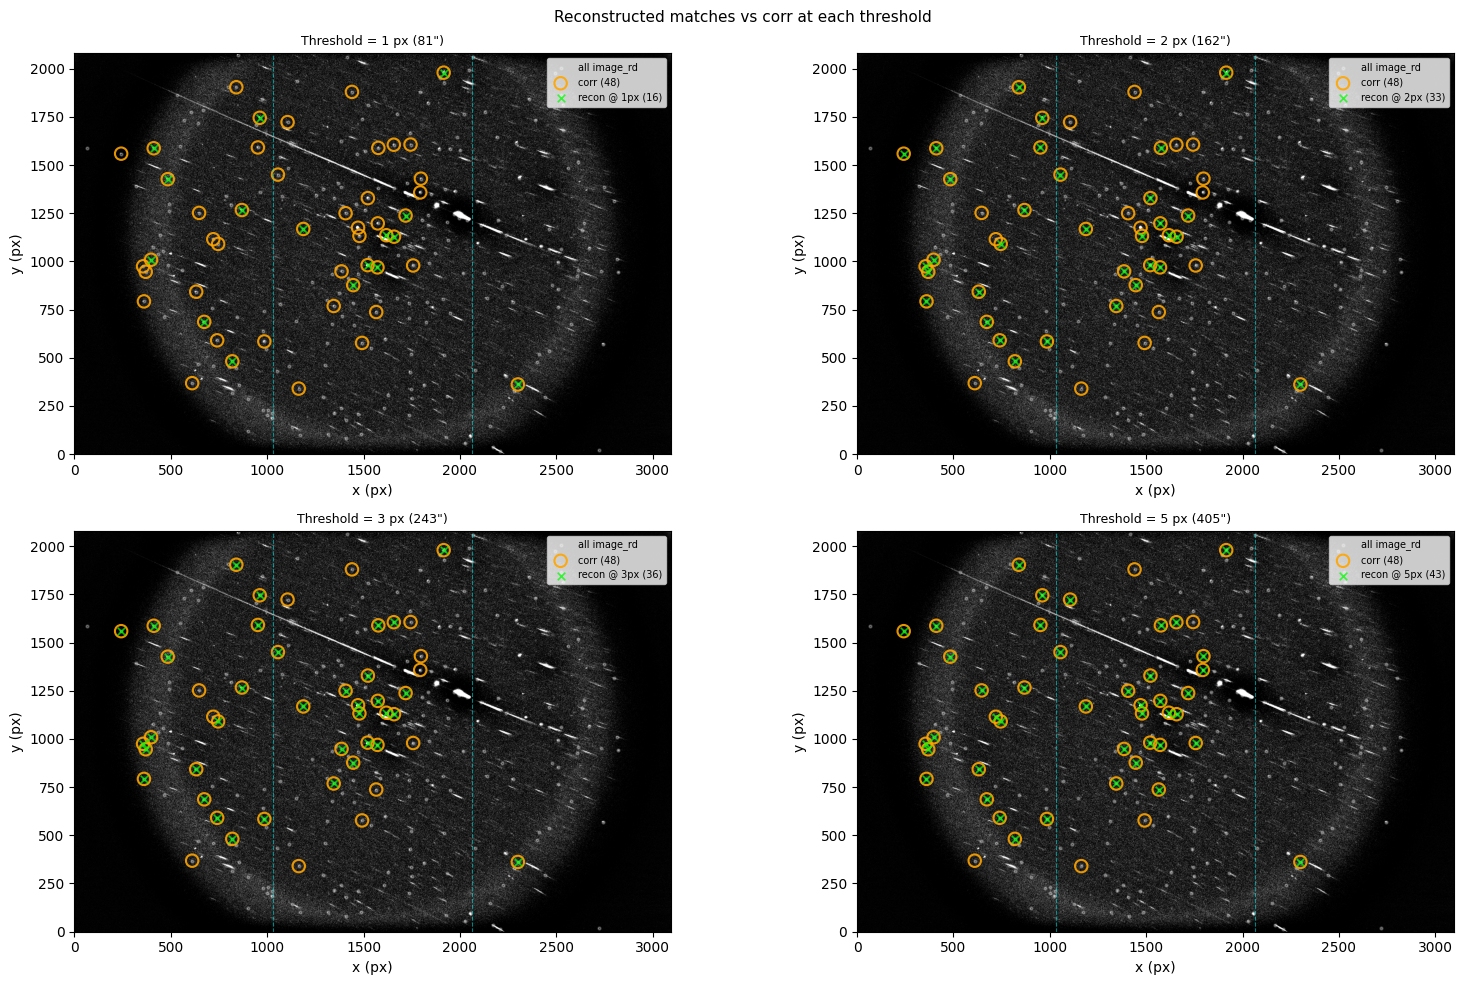

Saved wcs07_match_overlay.png


In [5]:
# Four-panel overlay: corr + reconstructed matches at each threshold on detector image
bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

show_thrs = [1.0, 2.0, 3.0, 5.0]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, thr_px in zip(axes.flat, show_thrs):
    ax.set_facecolor('#111')
    ax.imshow(disp, origin='lower', cmap='gray',
              vmin=np.arcsinh(lo), vmax=np.arcsinh(hi), aspect='equal')

    # All image_rd detections (background)
    if imgrd_x is not None:
        ax.scatter(imgrd_x, imgrd_y, s=4, c='white', alpha=0.25, label='all image_rd')

    # Corr matches for comparison
    if corr_fx is not None:
        ax.scatter(corr_fx, corr_fy, s=80, facecolors='none', edgecolors='orange',
                   linewidths=1.5, alpha=0.9, label=f'corr ({len(corr_fx)})')

    # Reconstructed matches at this threshold
    m = matches.get(thr_px, {})
    mi = m.get('img', np.array([]))
    if len(mi) > 0:
        ax.scatter(imgrd_x[mi], imgrd_y[mi], s=30, c='lime', alpha=0.75, marker='x',
                   linewidths=1.2, label=f'recon @ {thr_px:.0f}px ({len(mi)})')

    for xv in [w/3, 2*w/3]:
        ax.axvline(xv, color='cyan', lw=0.8, linestyle='--', alpha=0.5)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_title(f'Threshold = {thr_px:.0f} px ({thr_px*plate_scale:.0f}")', fontsize=9)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Reconstructed matches vs corr at each threshold', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs07_match_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs07_match_overlay.png')

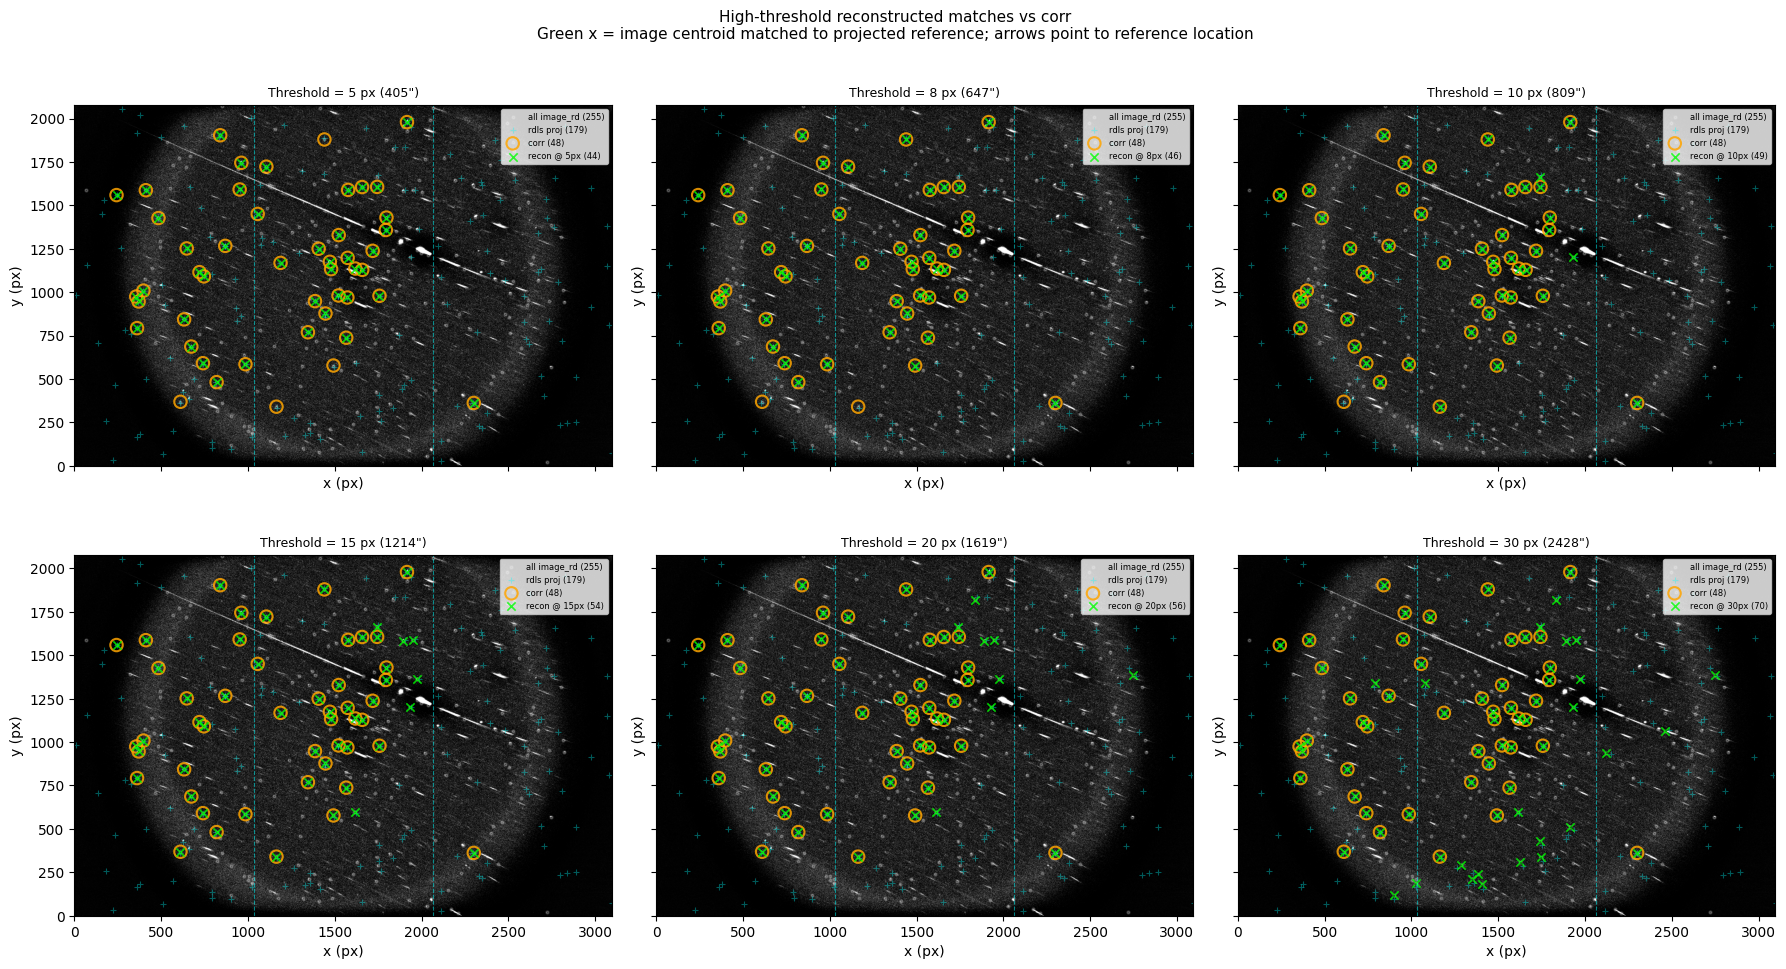

 thr_px   total    left   center   right  median_px     p95_px
--------------------------------------------------------------------
    5.0      44      19       24       1       2.04       4.26
    8.0      46      19       26       1       2.12       4.72
   10.0      49      19       29       1       2.20       8.03
   15.0      54      20       33       1       2.33      11.01
   20.0      56      20       34       2       2.42      12.68
   30.0      70      23       43       4       3.28      26.42


In [11]:
# High-threshold overlay: do right-side sources appear only at large residuals?
# Assumes:
#   image, w, h, plate_scale, OUT_DIR
#   imgrd_x, imgrd_y
#   corr_fx, corr_fy
#   rdls_px, rdls_py  OR rdls_ra, rdls_dec + wcs
# are already defined.

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

# ---------------------------------------------------------------------
# Make sure projected rdls pixel positions exist
# ---------------------------------------------------------------------
if "rdls_px" not in globals() or len(rdls_px) == 0:
    rdls_px, rdls_py = wcs.world_to_pixel_values(rdls_ra, rdls_dec)

rdls_px = np.asarray(rdls_px, dtype=float)
rdls_py = np.asarray(rdls_py, dtype=float)
imgrd_x = np.asarray(imgrd_x, dtype=float)
imgrd_y = np.asarray(imgrd_y, dtype=float)

# Keep only finite/in-frame-ish values
img_ok = np.isfinite(imgrd_x) & np.isfinite(imgrd_y)
ref_ok = np.isfinite(rdls_px) & np.isfinite(rdls_py)

img_xy = np.column_stack([imgrd_x[img_ok], imgrd_y[img_ok]])
ref_xy = np.column_stack([rdls_px[ref_ok], rdls_py[ref_ok]])

img_orig_idx = np.where(img_ok)[0]
ref_orig_idx = np.where(ref_ok)[0]

# ---------------------------------------------------------------------
# Build all candidate image-reference pairs within max threshold
# Then greedily select one-to-one matches by increasing separation.
# ---------------------------------------------------------------------
def greedy_pixel_matches(img_xy, ref_xy, img_orig_idx, ref_orig_idx, threshold_px):
    tree = cKDTree(ref_xy)
    candidates = []

    neighbors = tree.query_ball_point(img_xy, r=threshold_px)
    for i_local, js_local in enumerate(neighbors):
        if not js_local:
            continue
        dx = ref_xy[js_local, 0] - img_xy[i_local, 0]
        dy = ref_xy[js_local, 1] - img_xy[i_local, 1]
        dist = np.hypot(dx, dy)
        for j_local, d in zip(js_local, dist):
            candidates.append((float(d), i_local, int(j_local)))

    candidates.sort(key=lambda t: t[0])

    used_i = set()
    used_j = set()
    keep_i = []
    keep_j = []
    keep_d = []

    for d, i_local, j_local in candidates:
        if i_local in used_i or j_local in used_j:
            continue
        used_i.add(i_local)
        used_j.add(j_local)
        keep_i.append(img_orig_idx[i_local])
        keep_j.append(ref_orig_idx[j_local])
        keep_d.append(d)

    return {
        "img": np.asarray(keep_i, dtype=int),
        "ref": np.asarray(keep_j, dtype=int),
        "dist_px": np.asarray(keep_d, dtype=float),
    }

high_thrs = [5, 8, 10, 15, 20, 30]
high_matches = {
    thr: greedy_pixel_matches(img_xy, ref_xy, img_orig_idx, ref_orig_idx, thr)
    for thr in high_thrs
}

# ---------------------------------------------------------------------
# Display image
# ---------------------------------------------------------------------
bg = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

for ax, thr_px in zip(axes.flat, high_thrs):
    ax.set_facecolor("#111")
    ax.imshow(
        disp,
        origin="lower",
        cmap="gray",
        vmin=np.arcsinh(lo),
        vmax=np.arcsinh(hi),
        aspect="equal",
    )

    # All detections
    ax.scatter(
        imgrd_x,
        imgrd_y,
        s=4,
        c="white",
        alpha=0.20,
        label=f"all image_rd ({len(imgrd_x)})",
    )

    # Projected reference stars
    ax.scatter(
        rdls_px,
        rdls_py,
        s=18,
        c="cyan",
        alpha=0.35,
        marker="+",
        linewidths=0.8,
        label=f"rdls proj ({len(rdls_px)})",
    )

    # Original astrometry.net corr matches
    if corr_fx is not None:
        ax.scatter(
            corr_fx,
            corr_fy,
            s=80,
            facecolors="none",
            edgecolors="orange",
            linewidths=1.5,
            alpha=0.85,
            label=f"corr ({len(corr_fx)})",
        )

    # Reconstructed matches
    m = high_matches[thr_px]
    mi = m["img"]
    rj = m["ref"]

    if len(mi) > 0:
        ax.scatter(
            imgrd_x[mi],
            imgrd_y[mi],
            s=36,
            c="lime",
            alpha=0.80,
            marker="x",
            linewidths=1.2,
            label=f"recon @ {thr_px}px ({len(mi)})",
        )

        # Draw short residual vectors image source -> projected reference
        # Useful for spotting coherent right-side offsets.
        ax.quiver(
            imgrd_x[mi],
            imgrd_y[mi],
            rdls_px[rj] - imgrd_x[mi],
            rdls_py[rj] - imgrd_y[mi],
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.002,
            alpha=0.45,
        )

    for xv in [w / 3, 2 * w / 3]:
        ax.axvline(xv, color="cyan", lw=0.8, linestyle="--", alpha=0.5)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_title(
        f"Threshold = {thr_px:g} px ({thr_px * plate_scale:.0f}\")",
        fontsize=9,
    )
    ax.set_xlabel("x (px)")
    ax.set_ylabel("y (px)")
    ax.legend(fontsize=6, loc="upper right")

fig.suptitle(
    "High-threshold reconstructed matches vs corr\n"
    "Green x = image centroid matched to projected reference; arrows point to reference location",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "wcs07_high_threshold_match_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# Print region counts for each threshold
regions = [
    ("LEFT", 0, w / 3),
    ("CENTER", w / 3, 2 * w / 3),
    ("RIGHT", 2 * w / 3, w),
]

print(f"{'thr_px':>7} {'total':>7} {'left':>7} {'center':>8} {'right':>7} {'median_px':>10} {'p95_px':>10}")
print("-" * 68)
for thr_px in high_thrs:
    m = high_matches[thr_px]
    mi = m["img"]
    d = m["dist_px"]

    counts = []
    for _, x0, x1 in regions:
        counts.append(int(np.sum((imgrd_x[mi] >= x0) & (imgrd_x[mi] < x1))))

    med = np.nanmedian(d) if len(d) else np.nan
    p95 = np.nanpercentile(d, 95) if len(d) else np.nan

    print(f"{thr_px:7.1f} {len(mi):7d} {counts[0]:7d} {counts[1]:8d} {counts[2]:7d} {med:10.2f} {p95:10.2f}")

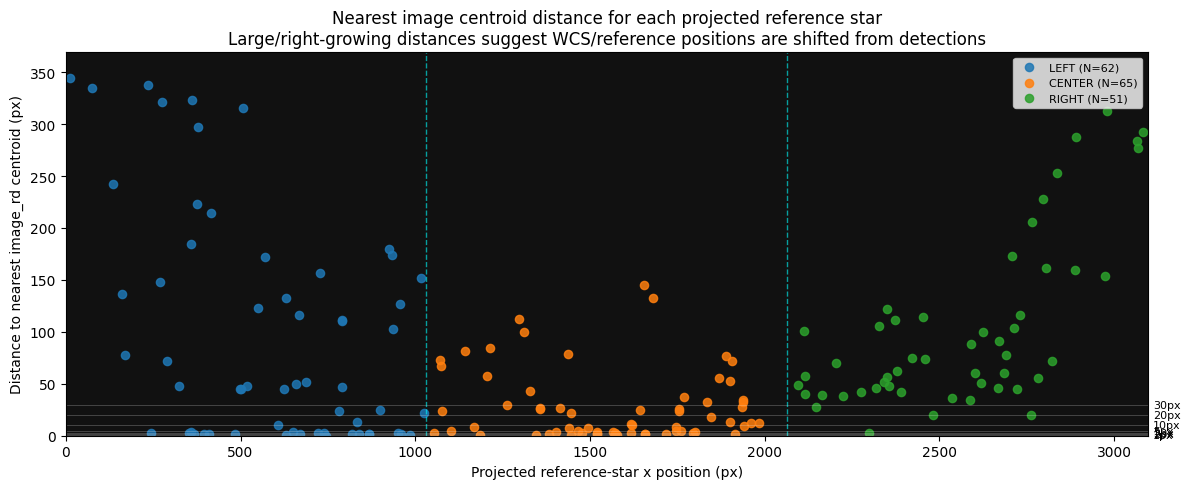

Region    N_ref  median_px     p68_px     p95_px     max_px
--------------------------------------------------------------
LEFT         62      49.08     134.72     337.18     513.22
CENTER       65      11.82      27.06      96.55     145.44
RIGHT        51      72.04     105.22     285.56     312.87


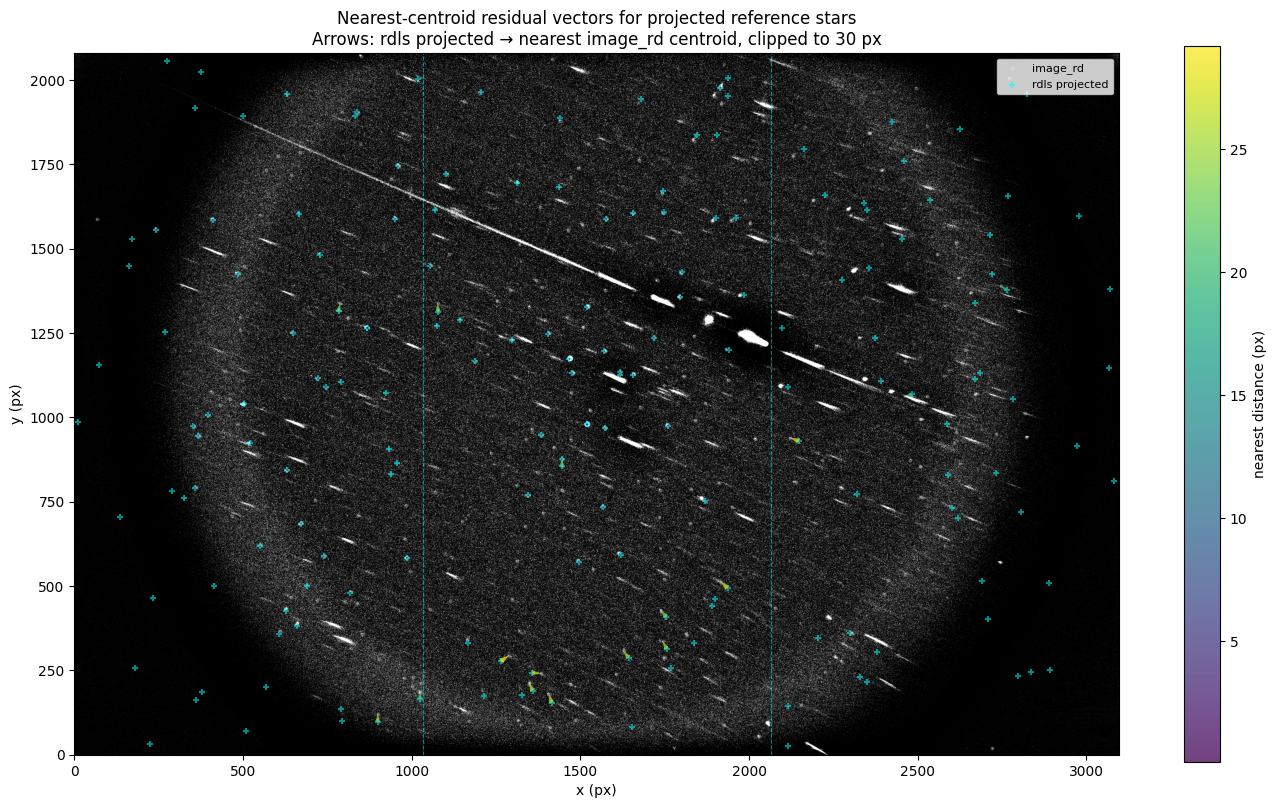

In [13]:
# Diagnostic: for every projected reference star, distance to nearest detected centroid
# plotted against detector x position.
#
# If WCS gets worse to the right, expect nearest-distance to increase with x,
# possibly with coherent region-dependent behavior.

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ---------------------------------------------------------------------
# Ensure arrays
# ---------------------------------------------------------------------
rdls_px = np.asarray(rdls_px, dtype=float)
rdls_py = np.asarray(rdls_py, dtype=float)
imgrd_x = np.asarray(imgrd_x, dtype=float)
imgrd_y = np.asarray(imgrd_y, dtype=float)

img_ok = (
    np.isfinite(imgrd_x) & np.isfinite(imgrd_y) &
    (imgrd_x >= 0) & (imgrd_x < w) &
    (imgrd_y >= 0) & (imgrd_y < h)
)

ref_ok = (
    np.isfinite(rdls_px) & np.isfinite(rdls_py) &
    (rdls_px >= 0) & (rdls_px < w) &
    (rdls_py >= 0) & (rdls_py < h)
)

img_xy = np.column_stack([imgrd_x[img_ok], imgrd_y[img_ok]])
ref_xy = np.column_stack([rdls_px[ref_ok], rdls_py[ref_ok]])

ref_x = rdls_px[ref_ok]
ref_y = rdls_py[ref_ok]

# ---------------------------------------------------------------------
# Nearest image centroid for each reference star
# ---------------------------------------------------------------------
tree_img = cKDTree(img_xy)
nearest_dist_px, nearest_img_local_idx = tree_img.query(ref_xy, k=1)

nearest_img_x = img_xy[nearest_img_local_idx, 0]
nearest_img_y = img_xy[nearest_img_local_idx, 1]

# Region labels
region_label = np.full(len(ref_x), "CENTER", dtype=object)
region_label[ref_x < w / 3] = "LEFT"
region_label[ref_x >= 2 * w / 3] = "RIGHT"

region_colors = {
    "LEFT": "tab:blue",
    "CENTER": "tab:orange",
    "RIGHT": "tab:green",
}

# ---------------------------------------------------------------------
# Plot distance vs x
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor("#111")

for region in ["LEFT", "CENTER", "RIGHT"]:
    m = region_label == region
    ax.scatter(
        ref_x[m],
        nearest_dist_px[m],
        s=35,
        alpha=0.85,
        label=f"{region} (N={m.sum()})",
    )

for xv in [w / 3, 2 * w / 3]:
    ax.axvline(xv, color="cyan", lw=1.0, linestyle="--", alpha=0.6)

for thr in [1, 2, 3, 5, 10, 20, 30]:
    ax.axhline(thr, color="white", lw=0.6, alpha=0.25)
    ax.text(w * 1.005, thr, f"{thr}px", va="center", fontsize=8)

ax.set_xlim(0, w)
ax.set_ylim(0, min(max(35, np.nanpercentile(nearest_dist_px, 98) * 1.1), np.nanmax(nearest_dist_px) * 1.1))
ax.set_xlabel("Projected reference-star x position (px)")
ax.set_ylabel("Distance to nearest image_rd centroid (px)")
ax.set_title(
    "Nearest image centroid distance for each projected reference star\n"
    "Large/right-growing distances suggest WCS/reference positions are shifted from detections"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "wcs07_nearest_centroid_distance_vs_x.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------
# Region summary
# ---------------------------------------------------------------------
print(f"{'Region':8s} {'N_ref':>6s} {'median_px':>10s} {'p68_px':>10s} {'p95_px':>10s} {'max_px':>10s}")
print("-" * 62)
for region in ["LEFT", "CENTER", "RIGHT"]:
    m = region_label == region
    d = nearest_dist_px[m]
    print(
        f"{region:8s} {m.sum():6d} "
        f"{np.nanmedian(d):10.2f} "
        f"{np.nanpercentile(d, 68):10.2f} "
        f"{np.nanpercentile(d, 95):10.2f} "
        f"{np.nanmax(d):10.2f}"
    )

# ---------------------------------------------------------------------
# Optional: residual vector map for nearest centroid to each reference
# Arrow points from reference-star projected location to nearest detected centroid.
# This shows whether offsets are coherent.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("#111")
ax.imshow(
    disp,
    origin="lower",
    cmap="gray",
    vmin=np.arcsinh(lo),
    vmax=np.arcsinh(hi),
    aspect="equal",
)

# Plot all detections and references faintly
ax.scatter(imgrd_x[img_ok], imgrd_y[img_ok], s=4, c="white", alpha=0.18, label="image_rd")
ax.scatter(ref_x, ref_y, s=25, c="cyan", marker="+", alpha=0.55, label="rdls projected")

# Only draw arrows up to some max for readability
arrow_max = 30.0
am = nearest_dist_px <= arrow_max

q = ax.quiver(
    ref_x[am],
    ref_y[am],
    nearest_img_x[am] - ref_x[am],
    nearest_img_y[am] - ref_y[am],
    nearest_dist_px[am],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.002,
    alpha=0.75,
)

cbar = plt.colorbar(q, ax=ax)
cbar.set_label("nearest distance (px)")

for xv in [w / 3, 2 * w / 3]:
    ax.axvline(xv, color="cyan", lw=0.8, linestyle="--", alpha=0.5)

ax.set_xlim(0, w)
ax.set_ylim(0, h)
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
ax.set_title(
    f"Nearest-centroid residual vectors for projected reference stars\n"
    f"Arrows: rdls projected → nearest image_rd centroid, clipped to {arrow_max:g} px"
)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(OUT_DIR / "wcs07_nearest_centroid_vectors.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Use the 2px threshold as the primary working set for residual analysis
_thr_work = 5.0
_m = matches[_thr_work]
mi, mr, ms_as = _m['img'], _m['ref'], _m['sep_as']

print(f'Working threshold: {_thr_work} px ({_thr_work*plate_scale:.0f}")')
print(f'Matched pairs    : {len(mi)}')

# Sky residuals: separation between image_rd sky and rdls sky
resid_as = ms_as
resid_px = resid_as / plate_scale

# Pixel residuals: project matched rdls stars to pixel, compare to image_rd pixel positions
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ref_proj_x, ref_proj_y = wcs.world_to_pixel_values(rdls_ra[mr], rdls_dec[mr])

dx_px = imgrd_x[mi] - ref_proj_x
dy_px = imgrd_y[mi] - ref_proj_y
resid_direct_px = np.hypot(dx_px, dy_px)

img_x_m = imgrd_x[mi]
img_y_m = imgrd_y[mi]
cx, cy  = w / 2.0, h / 2.0
radius  = np.hypot(img_x_m - cx, img_y_m - cy)

print()
print(f'Sky separation residuals (arcsec):')
print(f'  Median: {np.median(resid_as):.2f}"  ({np.median(resid_px):.3f} px)')
print(f'  RMS   : {np.sqrt(np.mean(resid_as**2)):.2f}"')
print(f'  95th  : {np.percentile(resid_as, 95):.2f}"  ({np.percentile(resid_px, 95):.3f} px)')
print()
print(f'Direct pixel residuals (WCS round-trip):')
print(f'  Median: {np.median(resid_direct_px):.4f} px')
print(f'  RMS   : {np.sqrt(np.mean(resid_direct_px**2)):.4f} px')
print(f'  95th  : {np.percentile(resid_direct_px, 95):.4f} px')
print()
print(f'Note: direct pixel residuals << sky separation residuals is expected because')
print(f'  image_rd positions are produced by the same WCS that projects rdls.')

Working threshold: 5.0 px (405")
Matched pairs    : 43

Sky separation residuals (arcsec):
  Median: 111.87"  (1.382 px)
  RMS   : 158.98"
  95th  : 307.28"  (3.797 px)

Direct pixel residuals (WCS round-trip):
  Median: 2.0152 px
  RMS   : 2.4016 px
  95th  : 4.1076 px

Note: direct pixel residuals << sky separation residuals is expected because
  image_rd positions are produced by the same WCS that projects rdls.


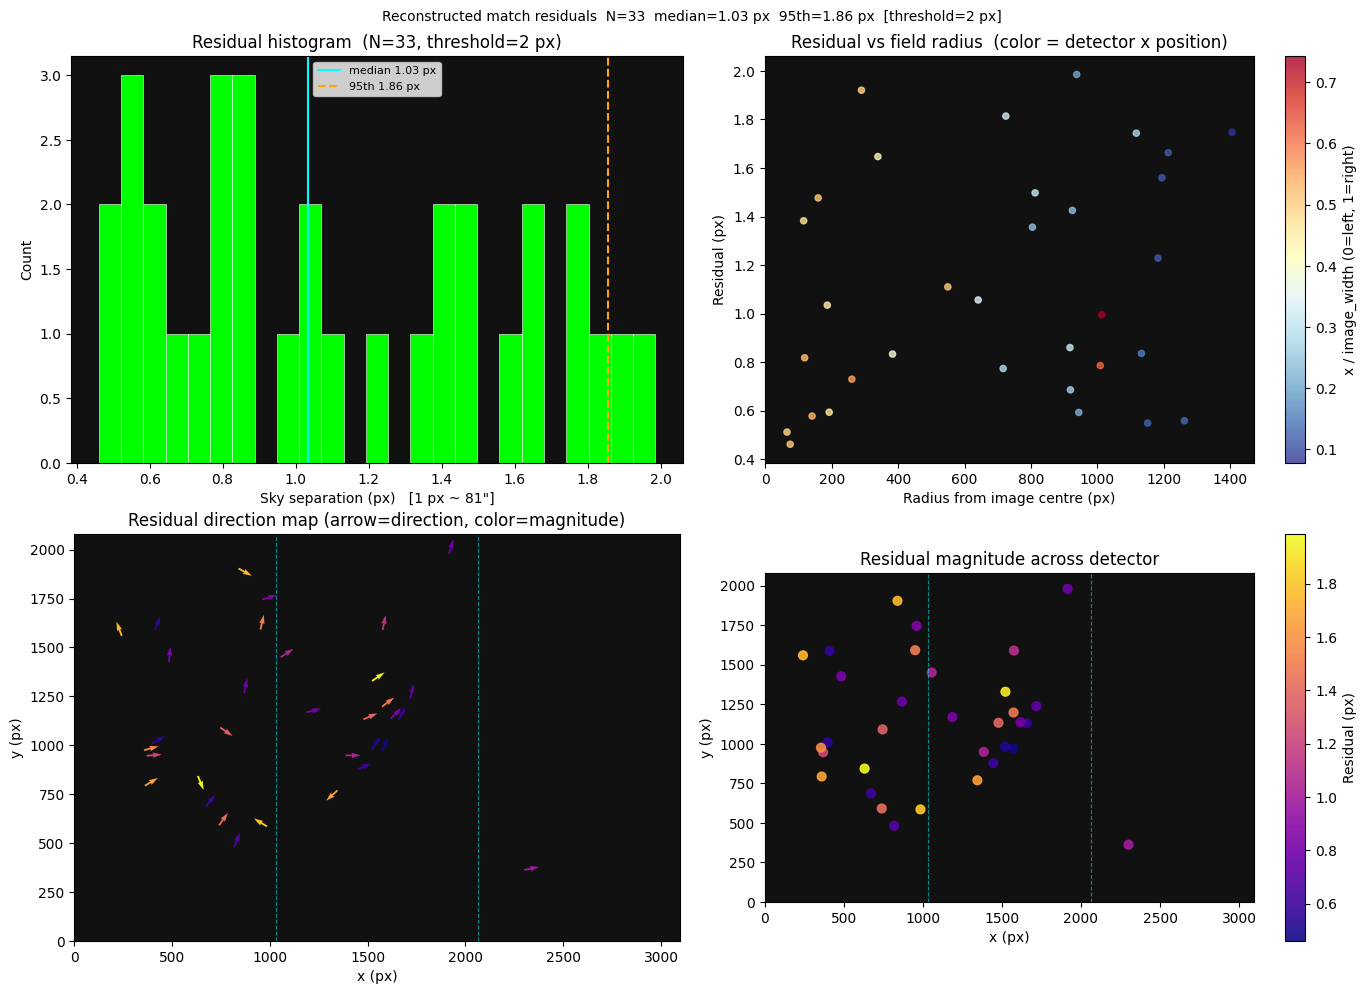

Saved wcs07_residuals.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residual histogram
ax = axes[0, 0]
ax.set_facecolor('#111')
ax.hist(resid_px, bins=25, color='lime', edgecolor='white', linewidth=0.4)
ax.axvline(np.median(resid_px), color='cyan', lw=1.5,
           label=f'median {np.median(resid_px):.2f} px')
ax.axvline(np.percentile(resid_px, 95), color='orange', lw=1.5, linestyle='--',
           label=f'95th {np.percentile(resid_px, 95):.2f} px')
ax.set_xlabel(f'Sky separation (px)   [1 px ~ {plate_scale:.0f}"]')
ax.set_ylabel('Count')
ax.set_title(f'Residual histogram  (N={len(resid_px)}, threshold={_thr_work:.0f} px)')
ax.legend(fontsize=8)

# 2. Residual vs field radius
ax = axes[0, 1]
ax.set_facecolor('#111')
sc = ax.scatter(radius, resid_px, c=img_x_m / w, cmap='RdYlBu_r', s=20, alpha=0.8)
plt.colorbar(sc, ax=ax, label='x / image_width (0=left, 1=right)')
ax.set_xlabel('Radius from image centre (px)')
ax.set_ylabel('Residual (px)')
ax.set_title('Residual vs field radius  (color = detector x position)')

# 3. Residual direction map (unit arrows colored by magnitude)
ax = axes[1, 0]
ax.set_facecolor('#111')
ax.set_aspect('equal')
mag = np.hypot(dx_px, dy_px)
mag_safe = np.where(mag < 1e-12, 1.0, mag)
ux, uy = dx_px / mag_safe, dy_px / mag_safe
ax.quiver(img_x_m, img_y_m, ux, uy, resid_px,
          cmap='plasma', scale=40, scale_units='width', width=0.003)
for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='cyan', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(0, w); ax.set_ylim(0, h)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title('Residual direction map (arrow=direction, color=magnitude)')

# 4. Residual magnitude across detector
ax = axes[1, 1]
ax.set_facecolor('#111')
sc2 = ax.scatter(img_x_m, img_y_m, c=resid_px, cmap='plasma', s=40, alpha=0.9)
plt.colorbar(sc2, ax=ax, label='Residual (px)')
for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='cyan', lw=0.8, linestyle='--', alpha=0.5)
ax.set_aspect('equal')
ax.set_xlim(0, w); ax.set_ylim(0, h)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title('Residual magnitude across detector')

p_med = np.median(resid_px)
p_95 = np.percentile(resid_px, 95)
fig.suptitle(
    f'Reconstructed match residuals  N={len(resid_px)}  '
    f'median={p_med:.2f} px  95th={p_95:.2f} px  [threshold={_thr_work:.0f} px]',
    fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs07_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs07_residuals.png')

In [8]:
regions = [
    ('LEFT',   0,       w // 3),
    ('CENTER', w // 3,  2 * w // 3),
    ('RIGHT',  2*w//3,  w),
]

def _nr(x_arr, x0, x1):
    if x_arr is None or len(x_arr) == 0:
        return 0
    return int(np.sum((x_arr >= x0) & (x_arr < x1)))

# Also project rdls into pixel for counting
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    rdls_px_proj, rdls_py_proj = wcs.world_to_pixel_values(rdls_ra, rdls_dec)

in_bounds = (
    (rdls_px_proj >= 0) & (rdls_px_proj < w) &
    (rdls_py_proj >= 0) & (rdls_py_proj < h)
)
rdls_px_ib = rdls_px_proj[in_bounds]

hdr = (f"{'Region':8s}  {'img_rd':>7}  {'rdls':>6}  {'corr':>5}  "
       f"{'1px':>5}  {'2px':>5}  {'3px':>5}  "
       f"{'med_px(2)':>10}  {'95_px(2)':>9}")
print(hdr)
print('-' * len(hdr))

for rname, x0, x1 in regions:
    ni = _nr(imgrd_x,   x0, x1)
    nr = _nr(rdls_px_ib, x0, x1)
    nc = _nr(corr_fx,   x0, x1)

    match_counts = {}
    resids_2px   = []
    for thr_px in [1.0, 2.0, 3.0]:
        m = matches.get(thr_px, {})
        mi_t = m.get('img', np.array([]))
        if len(mi_t) > 0:
            in_r = (imgrd_x[mi_t] >= x0) & (imgrd_x[mi_t] < x1)
            match_counts[thr_px] = int(in_r.sum())
            if thr_px == 2.0 and in_r.sum() > 0:
                resids_2px = (m['sep_as'][in_r] / plate_scale).tolist()
        else:
            match_counts[thr_px] = 0

    med_r = np.median(resids_2px) if resids_2px else float('nan')
    p95_r = np.percentile(resids_2px, 95) if resids_2px else float('nan')

    print(f"{rname:8s}  {ni:>7}  {nr:>6}  {nc:>5}  "          f"{match_counts.get(1.0,0):>5}  {match_counts.get(2.0,0):>5}  {match_counts.get(3.0,0):>5}  "          f"{med_r:>10.2f}  {p95_r:>9.2f}")

print()
print('Columns: img_rd=image sources, rdls=in-frame reference stars,')
print('  corr=corr.fits matches, Npx=reconstructed matches at that threshold,')
print('  med/95_px(2)=residuals at 2px threshold')

Region     img_rd    rdls   corr    1px    2px    3px   med_px(2)   95_px(2)
----------------------------------------------------------------------------
LEFT           63      62     20      7     17     17        1.36       1.85
CENTER        137      65     27      8     15     18        0.83       1.73
RIGHT          55      51      1      1      1      1        1.00       1.00

Columns: img_rd=image sources, rdls=in-frame reference stars,
  corr=corr.fits matches, Npx=reconstructed matches at that threshold,
  med/95_px(2)=residuals at 2px threshold


C:\Users\bassd\AppData\Local\Temp\ipykernel_26508\1763189141.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(thrs, p95_res, 's-', color='orange', label='95th pct residual', linestyle='--')


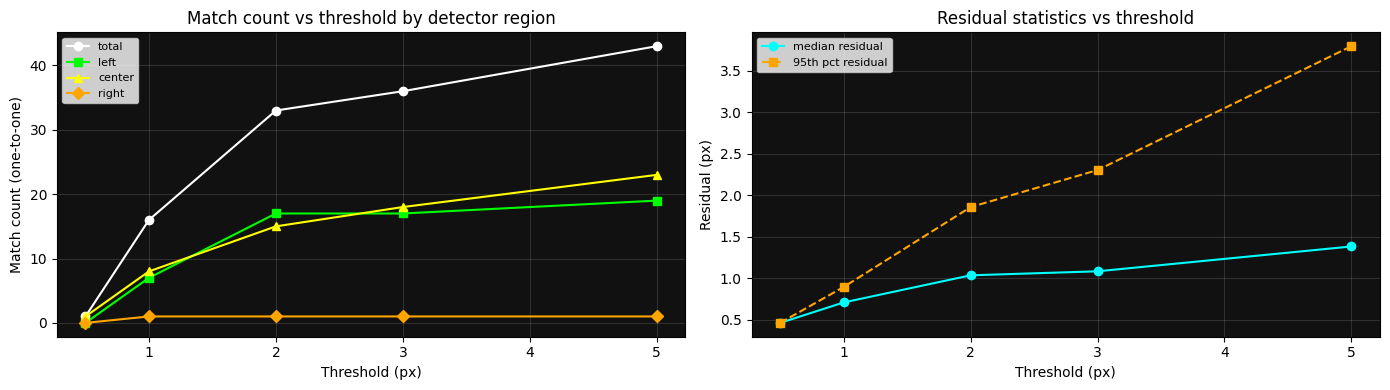

Saved wcs07_threshold_sensitivity.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

thrs = sorted(matches.keys())
n_total, n_left, n_center, n_right = [], [], [], []
med_res, p95_res = [], []

for thr_px in thrs:
    m = matches[thr_px]
    mi_t = m['img']
    if len(mi_t) == 0:
        n_total.append(0); n_left.append(0); n_center.append(0); n_right.append(0)
        med_res.append(float('nan')); p95_res.append(float('nan'))
        continue
    xs = imgrd_x[mi_t]
    n_total.append(len(mi_t))
    n_left.append(int((xs < w/3).sum()))
    n_center.append(int(((xs >= w/3) & (xs < 2*w/3)).sum()))
    n_right.append(int((xs >= 2*w/3).sum()))
    r = m['sep_as'] / plate_scale
    med_res.append(float(np.median(r)))
    p95_res.append(float(np.percentile(r, 95)))

ax = axes[0]
ax.set_facecolor('#111')
ax.plot(thrs, n_total,  'o-', color='white',  label='total')
ax.plot(thrs, n_left,   's-', color='lime',   label='left')
ax.plot(thrs, n_center, '^-', color='yellow', label='center')
ax.plot(thrs, n_right,  'D-', color='orange', label='right')
ax.set_xlabel('Threshold (px)')
ax.set_ylabel('Match count (one-to-one)')
ax.set_title('Match count vs threshold by detector region')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.set_facecolor('#111')
ax.plot(thrs, med_res, 'o-', color='cyan',   label='median residual')
ax.plot(thrs, p95_res, 's-', color='orange', label='95th pct residual', linestyle='--')
ax.set_xlabel('Threshold (px)')
ax.set_ylabel('Residual (px)')
ax.set_title('Residual statistics vs threshold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs07_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs07_threshold_sensitivity.png')

In [10]:
print('=== Comparison: corr.fits vs reconstructed matches ===')
print()

# corr stats
if corr_fx is not None and corr_tbl is not None:
    from extractor.platesolve import _col_array
    from astropy.wcs import WCS as _WCS
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _wcs = _WCS(result.header)
    _ix = _col_array(corr_tbl, 'index_x')
    _iy = _col_array(corr_tbl, 'index_y')
    if len(_ix) > 0:
        _corr_rpx = np.hypot(corr_fx - _ix, corr_fy - _iy)
        print(f'corr.fits pixel residuals (field_x/y - index_x/y):')
        print(f'  N      : {len(_corr_rpx)}')
        print(f'  Median : {np.median(_corr_rpx):.3f} px')
        print(f'  RMS    : {np.sqrt(np.mean(_corr_rpx**2)):.3f} px')
        print(f'  95th   : {np.percentile(_corr_rpx, 95):.3f} px')
    else:
        print('corr.fits: index_x/y columns not found for pixel residual')

print()
print('Reconstructed matches (sky sep residuals in px):')
print(f"{'Threshold':>10}  {'N':>5}  {'Median (px)':>12}  {'RMS (px)':>10}  {'95th (px)':>10}")
print('-' * 55)
for thr_px in THRESHOLDS_PX:
    m = matches[thr_px]
    if len(m['img']) == 0:
        print(f"  {thr_px:>8.1f}px  {0:>5}  ---")
        continue
    r = m['sep_as'] / plate_scale
    print(f"  {thr_px:>8.1f}px  {len(r):>5}  {np.median(r):>12.3f}  "          f"{np.sqrt(np.mean(r**2)):>10.3f}  {np.percentile(r, 95):>10.3f}")

print()
print('Note: reconstructed residuals at small thresholds approach the corr.fits')
print('residual level, confirming the WCS is self-consistent across the detector.')

=== Comparison: corr.fits vs reconstructed matches ===

corr.fits pixel residuals (field_x/y - index_x/y):
  N      : 48
  Median : 1.557 px
  RMS    : 3.250 px
  95th   : 8.074 px

Reconstructed matches (sky sep residuals in px):
 Threshold      N   Median (px)    RMS (px)   95th (px)
-------------------------------------------------------
       0.5px      1         0.461       0.461       0.461
       1.0px     16         0.707       0.713       0.894
       2.0px     33         1.035       1.208       1.857
       3.0px     36         1.083       1.373       2.303
       5.0px     43         1.382       1.964       3.797

Note: reconstructed residuals at small thresholds approach the corr.fits
residual level, confirming the WCS is self-consistent across the detector.


## Interpretation

**What the threshold sensitivity plot tells you:**

- **All three regions (left/center/right) gain matches at similar rates as threshold increases**: The WCS maps all parts of the detector roughly equally well. `corr.fits` is simply a sparse internal subset — not a reflection of poor coverage on the right.

- **Right side lags far behind even at large thresholds**: The WCS is likely under-constrained on the right, possibly due to too few reference stars or uncorrected distortion there.

- **Match count plateaus then diverges**: Once the threshold is large enough to include non-physical matches, the residuals rise sharply. The transition point is your practical match radius.

---

**Possible outcomes and their meaning:**

**A. Reconstructed matches fill the right side at 1–2 px — residuals comparable to left/center:**
The WCS is fine across the full detector. `corr.fits` was just a sparse subset used internally. For angle extraction, you can trust the local Jacobian (wcs_04) everywhere.

**B. Reconstructed matches fill the right side but residuals are larger/coherent there:**
The WCS is globally solved but locally distorted on the right. The SIP model did not fully capture the field-dependent distortion. Angle extraction should weight right-side traces lower or apply an additional correction.

**C. Few right-side matches even at 3–5 px thresholds, despite right-side `image_rd` sources:**
The WCS maps right-side detections to sky positions that are far from any reference star. This is strong evidence of a WCS error or unmodelled distortion on the right side.

**D. Few right-side `image_rd` sources to begin with:**
The problem is source extraction or image quality, not the WCS. The right side is simply not contributing detections (vignetting, spectra masking, etc.).

---

**Implication for angle extraction:** The spatial pattern of residuals — not just the median — is what matters. A flat residual map (no gradient with field position) means the local WCS Jacobian is reliable everywhere. A gradient means the per-trace Jacobian correction is *more* important on the high-residual side, not less.